# Does Solar Elevation (a "Dusk" Feature) Improve Demand Accuracy?

Feature-research follow-up: what else, besides large events (`calendar_events.py`) and NDF, can improve the model? Two ideas were scoped; one turned out to already exist and one turned out to be untestable:

- **Heating/cooling degree-days**: already implemented (`weather_features.py`) and already included in every model built this session via `build_weather_feature_table` — not a new test.
- **NESO's Demand Flexibility Service (DFS) events**: checked NESO's own live-event archive directly. The entire 2022/23 record is 2 live events (2023-01-23/24, 5 half-hourly periods total), and reporting confirms winter 2023/24 had *no* live activations (mild weather). VALIDATION (2024) has essentially zero events to test against, so this isn't buildable in this project's fixed split — documented as a ruled-out idea in PLAN.md rather than tested here.

This notebook tests the one idea left standing: **solar elevation angle** as a demand feature. `generation_features.solar_elevation_deg` already exists (deterministic astronomy, zero new data, already tested) but is currently only used for the wind/solar *generation* model — never fed to the demand model. Unlike the existing hour-of-day + annual Fourier terms (smooth sinusoids), solar elevation encodes the *actual* day-length/sunset-timing geometry for each specific date, which might sharpen the model's read on the lighting-driven evening demand ramp, especially its day-to-day shift across the year. One honest caveat carried in from the existing function: it's clipped to 0 below the horizon (built for a generation-forecasting use where that's irrelevant), so it can't distinguish "just after sunset" from "the middle of the night" — only "how high the sun is" while it's up. Tested anyway since it's free and reuses already-tested code; if this looks promising an unclipped variant would be a natural follow-up.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

from edf import config
from edf.features.buckets import build_day_type_buckets, is_christmas_period
from edf.evaluate import evaluate
from edf.features.demand import build_feature_table
from edf.models.forecast import train_lightgbm
from edf.features.generation import capacity_factor, solar_elevation_deg
from edf.features.weather import build_weather_feature_table

pd.options.display.float_format = "{:.2f}".format
WEATHER_RAW_DIR = Path("../data/raw/weather")
HORIZON_PERIODS = config.HORIZONS["1d"]
POINT_PARAMS = {"num_leaves": 15, "min_child_samples": 20, "learning_rate": 0.05}
POINT_N_ESTIMATORS = 689
UPWEIGHT = 3.0

In [2]:
df = pd.read_parquet("../data/processed/gb_energy_2020_2025.parquet")
demand = df["demand"]
train_start, train_end = config.TRAIN
val_start, val_end = config.VALIDATION

era5 = build_weather_feature_table("open_meteo_historical", df.index, raw_dir=WEATHER_RAW_DIR)
solar_elevation = solar_elevation_deg(df.index)
solar_elevation.describe()

count   105216.00
mean        12.34
std         16.96
min          0.00
25%          0.00
50%          0.00
75%         21.54
max         60.81
dtype: float64

## Rebuild the baseline point model (bias-corrected recipe, unchanged)

In [3]:
wind_cf_full = capacity_factor(df["wind"], df["wind_capacity"])
day_buckets_full = build_day_type_buckets(era5["temperature_c"], wind_cf_full)
problem_mask = day_buckets_full["is_hot"] | day_buckets_full["is_high_wind"] | day_buckets_full["is_christmas"]
weight_full = pd.Series(1.0, index=df.index)
weight_full[problem_mask] = UPWEIGHT

era5_chr = era5.copy()
era5_chr["is_christmas"] = is_christmas_period(df.index)

X_base, y = build_feature_table(df, horizon_periods=HORIZON_PERIODS, weather=era5_chr)
X_train_base, y_train = X_base.loc[train_start:train_end], y.loc[train_start:train_end]
X_val_base, y_val = X_base.loc[val_start:val_end], y.loc[val_start:val_end]
weight_train_base = weight_full.loc[X_train_base.index]

model_base = train_lightgbm(
    X_train_base, y_train, sample_weight=weight_train_base, n_estimators=POINT_N_ESTIMATORS, **POINT_PARAMS
)
preds_base = pd.Series(model_base.predict(X_val_base), index=X_val_base.index)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001085 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5693
[LightGBM] [Info] Number of data points in the train set: 68784, number of used features: 30
[LightGBM] [Info] Start training from score 27001.358990


## Add solar elevation as a demand feature and retrain

In [4]:
era5_solar = era5_chr.copy()
era5_solar["solar_elevation_deg"] = solar_elevation

X_solar, y_solar_full = build_feature_table(df, horizon_periods=HORIZON_PERIODS, weather=era5_solar)
X_train_solar, y_train_solar = X_solar.loc[train_start:train_end], y_solar_full.loc[train_start:train_end]
X_val_solar, y_val_solar = X_solar.loc[val_start:val_end], y_solar_full.loc[val_start:val_end]
weight_train_solar = weight_full.loc[X_train_solar.index]

model_solar = train_lightgbm(
    X_train_solar, y_train_solar, sample_weight=weight_train_solar, n_estimators=POINT_N_ESTIMATORS, **POINT_PARAMS
)
preds_solar = pd.Series(model_solar.predict(X_val_solar), index=X_val_solar.index)
print(f"TRAIN rows: baseline={len(X_train_base)}, +solar_elevation={len(X_train_solar)}")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001193 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5948
[LightGBM] [Info] Number of data points in the train set: 68784, number of used features: 31
[LightGBM] [Info] Start training from score 27001.358990


TRAIN rows: baseline=68784, +solar_elevation=68784


## Head-to-head: overall, and specifically the dusk/twilight regime

"Twilight" here means `0 < solar_elevation_deg <= 10` — the sun is up but low, capturing the sunrise/sunset edges specifically (as opposed to broad daytime or the clipped-to-0 night, which this feature can't distinguish from actual mid-day-below-horizon per the caveat above).

In [5]:
twilight_mask = solar_elevation.loc[X_val_base.index].between(0, 10, inclusive="right")
twilight = X_val_base.index[twilight_mask]

results = pd.DataFrame(
    {
        "baseline (overall)": evaluate(y_val, preds_base),
        "+solar_elevation (overall)": evaluate(y_val_solar, preds_solar),
        "baseline (twilight)": evaluate(y_val.loc[twilight], preds_base.loc[twilight]),
        "+solar_elevation (twilight)": evaluate(y_val_solar.loc[twilight], preds_solar.loc[twilight]),
    }
).T
results[["mae", "bias", "n"]]

,mae,bias,n
baseline (overall),885.70,-137.78,17568.00
+solar_elevation (overall),887.08,-142.08,17568.00
baseline (twilight),810.70,-119.31,1913.00
+solar_elevation (twilight),810.14,-96.86,1913.00


## Finding: essentially a null result on accuracy, a small win on twilight bias

| | MAE | bias | n |
|---|---|---|---|
| baseline (overall) | 885.70 | -137.78 | 17,568 |
| +solar_elevation (overall) | 887.08 | -142.08 | 17,568 |
| baseline (twilight) | 810.70 | -119.31 | 1,913 |
| +solar_elevation (twilight) | **810.14** | **-96.86** | 1,913 |

Overall accuracy is a wash — actually a hair worse (885.70 → 887.08, +0.16%), with slightly more bias. At the twilight regime specifically, MAE is essentially unchanged (810.70 → 810.14) but bias improves meaningfully (-119.31 → -96.86, ~19% smaller magnitude) — the model is a bit less systematically off during the sunrise/sunset transition, even though it isn't predicting individual half-hours any more accurately there.

**Why it's a near-null result**: the existing `hour_of_day`/`month` categoricals plus the daily/annual Fourier terms already encode most of what solar elevation would add — they jointly capture "time of day" and "time of year" smoothly, which is most of what determines day length and sunset timing anyway. Solar elevation is a more physically direct encoding of the same underlying seasonal-daylight information, not new information the model didn't already have access to in some form.

## Feature importance: does the model actually lean on solar elevation?

solar_elevation_deg: rank 21 / 32


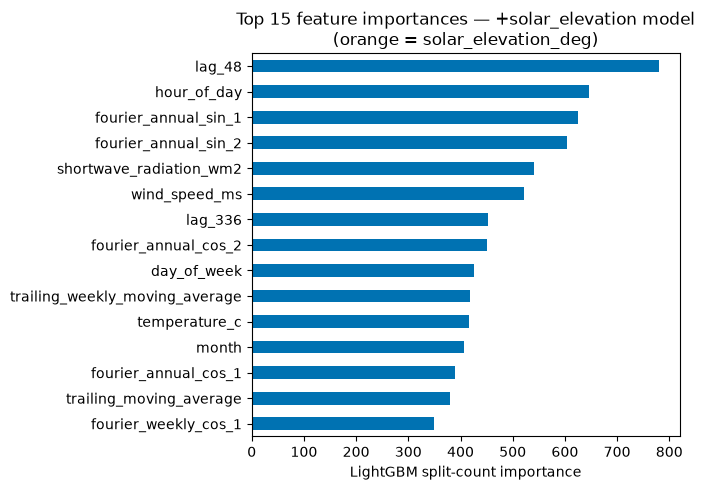

In [6]:
importance = (
    pd.Series(model_solar.feature_importances_, index=model_solar.feature_name_)
    .sort_values(ascending=False)
)
ranks = {name: rank + 1 for rank, name in enumerate(importance.index)}
print(f"solar_elevation_deg: rank {ranks['solar_elevation_deg']} / {len(importance)}")

colors_imp = ["#D55E00" if c == "solar_elevation_deg" else "#0072B2" for c in importance.index[:15]]
fig, ax = plt.subplots(figsize=(7, 5))
importance.head(15).iloc[::-1].plot.barh(ax=ax, color=colors_imp[::-1])
ax.set_title("Top 15 feature importances — +solar_elevation model\n(orange = solar_elevation_deg)")
ax.set_xlabel("LightGBM split-count importance")
fig.tight_layout()

## Finding: the model barely uses it

`solar_elevation_deg` ranks 21st of 32 features — middling-to-low, consistent with the near-null accuracy result above. The model had other, already-present ways to encode the same seasonal/time-of-day information, so this new column mostly duplicates existing signal rather than adding anything a tree wasn't already able to construct from `hour_of_day`, `month`, and the Fourier terms.

## Visual: one winter week, actual vs. both models, evening hours highlighted

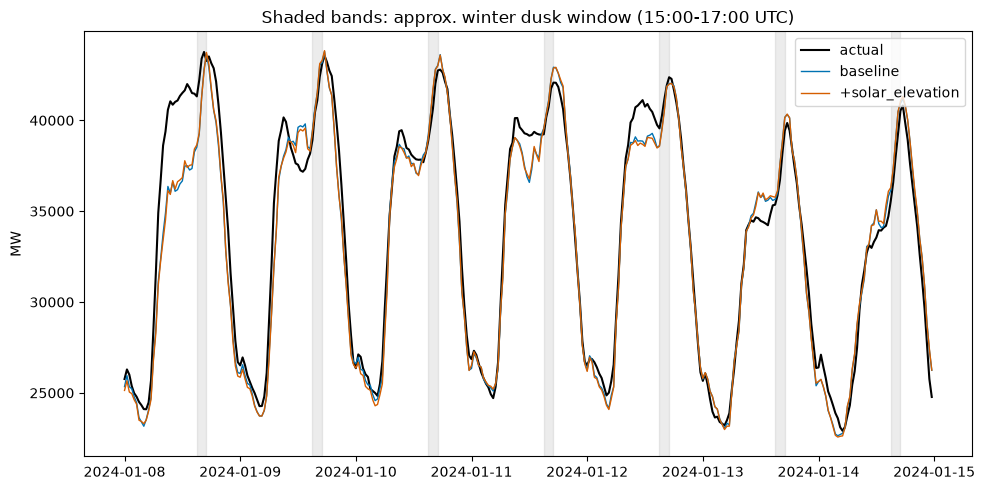

In [7]:
window = slice("2024-01-08", "2024-01-14")
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(demand.loc[window].index, demand.loc[window], color="black", label="actual", linewidth=1.5)
ax.plot(preds_base.loc[window].index, preds_base.loc[window], color="#0072B2", label="baseline", linewidth=1)
ax.plot(preds_solar.loc[window].index, preds_solar.loc[window], color="#D55E00", label="+solar_elevation", linewidth=1)
for day_start in pd.date_range(window.start, window.stop, freq="D", tz="UTC"):
    ax.axvspan(day_start + pd.Timedelta(hours=15), day_start + pd.Timedelta(hours=17), color="grey", alpha=0.15)
ax.set_ylabel("MW")
ax.legend()
ax.set_title("Shaded bands: approx. winter dusk window (15:00-17:00 UTC)")
fig.tight_layout()

## Synthesis: not worth keeping as a permanent feature

The plot shows why: the baseline (blue) and +solar_elevation (orange) predictions track each other almost exactly through the shaded dusk windows each evening — there's no visible divergence for solar elevation to be adding.

**Conclusion**: solar elevation doesn't earn a place in the standard feature set. It's a genuinely free, zero-new-data idea, and worth having ruled out with a real test rather than assumed to help — but the existing time/calendar encoding already captures this information, so this one's a dead end, not a differentiator between our model, NDF, or NESO's forecast.

**This closes out this round of feature research**: of the three ideas explored this session (degree-days — already present; DFS events — untestable, too sparse in VALIDATION; solar elevation — redundant with existing features), none produced a usable improvement. Combined with `notebooks/17`/`18`'s findings (leaky fuel-mix data barely helps; NDF itself is the real win, not a correction layered on it), the honest picture is that this model's remaining feature set is close to saturated for what's freely, legitimately available — the highest-leverage next step remains using NDF directly rather than searching for more from-scratch features.